# Final report on data challenge "Maintenance and Industry 4.0 2026"

## Group 2 - Members

- Óscar MARTINEZ ZAMORA
- Yiling ZHUANG
- Ahmed-Wassim BENZERGA

## Submission
- Please name your notebook as `final_submission_group_X.ipynb` and submit it via [here](https://nextcloud.centralesupelec.fr/s/bcGcQzimE4ZjetS)
- Deadline: 07/06/2026 23:59

## Methods

Instead of building a single model for the whole robot, we treated the problem as six separate binary
classification tasks, one per motor, that all run through the same pipeline but are tuned individually. We
did this because the six motors behave very differently from one another, both in how often they fail and in
what a failure looks like in their sensor traces. The sections below explain, one decision at a time, how the
data was organised, how we dealt with the heavy class imbalance, how we validated without leaking
information, how we generated synthetic faults, which features and model we used, and how we turned the
model's probabilities into final 0/1 predictions. The runnable pipeline that puts all of this together comes
after these explanations, and the per-motor results come at the very end.

### The data: original training set and additional data

We worked with two sources of labelled data.

The original training set is the one provided for the challenge (downloaded from the course platform). It
contains a handful of labelled sequences and is the data we used in our first attempts.

The additional data is a set of supplementary labelled datasets that we only started using later in the
project. Our first models, trained on the original data alone, did not reach a good F1 score, mainly because
some motors had almost no examples of failure to learn from. Adding the supplementary datasets gave the model
many more sequences (and many more fault examples for the rare motors), which is why all the results below are
produced on the combined data. The pipeline loads the original set first and then appends the additional
sets.

### The class-imbalance problem

This is a strongly imbalanced problem: in normal operation a motor is almost always healthy, so the fault
class is rare. The metric (macro F1 over the fault class) is chosen precisely because plain accuracy is
meaningless here (always predicting "healthy" would already score around 95% accuracy while detecting nothing).

The table below shows the percentage of data points labelled as a fault for each motor, over the whole
labelled dataset (original training set plus additional data, 99407 rows):

| Motor | Fault data points | Fault rate (whole dataset) |
|---|---|---|
| M1 | 3815 | 3.84% |
| M2 | 8096 | 8.14% |
| M3 | 834 | 0.84% |
| M4 | 8674 | 8.73% |
| M5 | 1622 | 1.63% |
| M6 | 2957 | 2.97% |

The imbalance is even more extreme if we look only at the original training set (39309 rows), which is what
motivated us to add the supplementary data and to generate synthetic faults. In the original data, Motors 3
and 5 have almost no failures at all (well under half a percent), so a classifier has essentially nothing to
learn from:

| Motor | Fault data points | Fault rate (original training set) |
|---|---|---|
| M1 | 1349 | 3.43% |
| M2 | 6732 | 17.13% |
| M3 | 127 | 0.32% |
| M4 | 6739 | 17.14% |
| M5 | 184 | 0.47% |
| M6 | 1932 | 4.91% |

The practical consequences are two: we must measure the fault class directly (not accuracy), and for the
rare motors (M1, M3, M5) we must create extra fault examples, which we do with synthetic injection below.

### Validation: whole sequences and K-fold (avoiding data leakage)

Samples that are close together in time are almost identical, because temperature changes very slowly. If we
split the data randomly row by row, rows from the same fault would land in both the training and the
validation set, and the model would effectively be tested on data it had already seen. That kind of leakage
produces a falsely high local F1 that collapses on the real leaderboard.

To prevent this we always validate by whole sequences: an entire sequence goes either to training or to
validation, never split across the two. The grouping unit is the sequence, not the row, so every fault block
in the validation set is one the model never saw during training.

Concretely, we hold out about 20% of the sequences for validation and train on the remaining 80%. The split
is stratified by sequence type: we set aside 20% of the fault-containing sequences and, separately, 20% of
the normal sequences, so the validation set is guaranteed to contain at least one real fault. With the
combined data this works out to roughly 48 training sequences and 11 validation sequences out of 59 (about
81% versus 19%). We use this leakage-free, per-sequence split both to choose the model hyperparameters and to
choose the decision threshold. Its only weakness is that the number of sequences containing real faults is
small, so the validation set is not very diverse, which we return to in the conclusions.

### Synthetic fault injection

Because Motors 1, 3 and 5 barely fail in the data, we generate extra fault examples so the model has
something to learn from. The idea is to take a healthy sequence and reshape a slice of its temperature trace
into a realistic failure signature, then label that slice as a fault. The next cell is the exact code we used
to inject a fault; the explanation follows it.

fault window length (n): 170 | rise ~ n/3, decay ~ 2n/3
peak reached (deg above baseline): 13.0


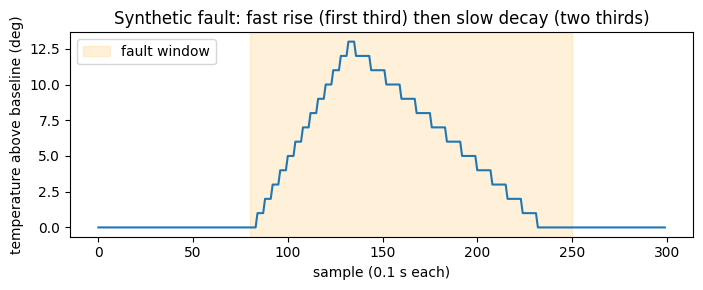

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# This is the exact synthetic-fault injection function used by the pipeline (shown here to explain it).
def inject_failure(temp, label, peak_low, peak_high):
    temp = np.asarray(temp, float).copy(); label = np.asarray(label); mask = label == 1
    tmp = temp[mask].copy(); n = len(tmp)            # n = length of the fault window
    if n == 0: return temp
    nr = max(1, n // 3); ts, te = tmp[0], tmp[-1]    # nr = rise length (first third)
    th = max(ts, te) + np.random.randint(peak_low, peak_high + 1)   # peak height above baseline
    rs = int(round(th - ts))                         # how many degrees to climb on the way up
    if rs >= 1:
        st = (nr // (rs + 1)) or 1; i = 0            # samples spent on each 1-degree step
        for i in range(1, rs + 1):
            lo, hi = (i - 1) * st, min(i * st, nr)
            if lo >= nr: break
            tmp[lo:hi] = ts + (i - 1)
        if i * st < nr: tmp[i * st:nr] = th
    ds = int(round(th - te))                         # how many degrees to fall on the way down
    if ds >= 1:
        st = (2 * nr // ds) or 1; i = 0              # decay spans the remaining two thirds (2*nr)
        for i in range(1, ds):
            lo, hi = nr + (i - 1) * st, min(nr + i * st, n)
            if lo >= n: break
            tmp[lo:hi] = th - i
        if nr + i * st < n: tmp[nr + i * st:] = te
    temp[mask] = tmp; return temp

# Demonstration: inject a fault into a flat 300-sample baseline and plot the resulting pulse.
np.random.seed(0)
demo = np.zeros(300)
lbl = np.zeros(300, int); lbl[80:250] = 1            # a 170-sample fault window
shaped = inject_failure(demo.copy(), lbl, peak_low=8, peak_high=16)
print('fault window length (n):', int(lbl.sum()), '| rise ~ n/3, decay ~ 2n/3')
print('peak reached (deg above baseline):', round(float(shaped.max()), 1))
plt.figure(figsize=(7, 3))
plt.plot(shaped); plt.axvspan(80, 250, color='orange', alpha=0.15, label='fault window')
plt.xlabel('sample (0.1 s each)'); plt.ylabel('temperature above baseline (deg)')
plt.title('Synthetic fault: fast rise (first third) then slow decay (two thirds)')
plt.legend(); plt.tight_layout(); plt.show()


#### How the injection works

The fault window is a random contiguous slice of a healthy sequence, between 120 and 400 samples long (12 to
40 seconds at 10 Hz). Inside that window the temperature is reshaped into a triangular pulse:

- A peak height is drawn at random between `peak_low` and `peak_high` degrees above the local baseline.
- The temperature climbs from the baseline to the peak over the first third of the window (`nr = n // 3`),
  one degree per step.
- It then decays from the peak back down to the end level over the remaining two thirds (`2 * nr`).

The rise is therefore faster than the decay, which matches a real thermal transient: a motor heats up quickly
when something goes wrong and cools down slowly afterwards. After the temperature is reshaped, all the derived
features (differences, rolling statistics, window shapes) are recomputed on the injected trace, so the
synthetic fault carries consistent dynamic features.

#### Per-motor injection choices

Where the fault is placed is chosen at random: for each synthetic example we pick a healthy sequence at
random and, inside it, a random start point and a random window length (between 120 and 400 samples). We only
draw the window from sequences that have no real fault for that motor, so we never overwrite a genuine
failure, and the random placement means the model sees faults beginning at many different moments rather than
always at the same position.

We tuned two knobs per motor: how many synthetic faults to inject, and how strong (the peak range). The
premises were simple. The motors that almost never fail (M3 and M5) get many injections so the model sees
enough examples, and those injections are subtle (a small peak) because their real faults are small. The
structurally hard motors (M1 and M4) get a larger peak so the synthetic signature is clear enough to anchor
the signal against the temperature-fault inversion. The frequently-failing motors already have plenty of real
faults, so they only need a modest top-up.

| Motor | Fault rate (orig.) | Injections | Peak rise (deg) | Premise for the choice |
|---|---|---|---|---|
| M1 | 3.43% | 4 | 8 to 16 | hardest motor; strong, clear pulses to anchor the signal |
| M2 | 17.13% | 4 | 2 to 10 | many real faults already; only a modest top-up |
| M3 | 0.32% | 16 | 3 to 8 | extremely rare; many subtle examples needed |
| M4 | 17.14% | 4 | 6 to 15 | many real faults but inversion-affected; stronger pulses |
| M5 | 0.47% | 16 | 1 to 4 | extremely rare; many very subtle examples needed |
| M6 | 4.91% | 4 | 6 to 15 | marked, contiguous faults; moderate pulses |

### Features: physical, rolling and dynamic

We did not feed the raw sensor values alone; we built a small set of features that describe both the state of
the motor and how that state is changing, using plain transformations:

- Physical features: temperature, position and voltage, each expressed relative to the start of the sequence.
  These describe where the motor is right now.
- Rolling features: rolling mean, maximum and standard deviation over short windows. These smooth out sensor
  noise and capture the recent local level and how much the signal is wobbling.
- Dynamic features: differences at several time lags and the deviation from a rolling mean. These describe how
  fast and in which direction the signal is moving. They matter because a fault shows up as a change over time
  rather than as a particular absolute value, and because the absolute temperature is unreliable (its
  relationship with the fault even flips sign between sequences).
- Window-shape features (used for Motor 1): skewness, kurtosis, slope and range over a window, which describe
  the shape of the thermal pulse rather than its level.

We keep both the physical and the dynamic/rolling families on purpose: the physical features alone miss the
temporal pattern of a fault, while the dynamic features alone lose the steady-state level. Together they
describe both the state and its evolution, which is what a fault detector needs.

#### The temperature-fault inversion

There is a specific difficulty that shaped our feature choices, especially for Motors 1 and 4. The two
sequences that contain real faults disagree on how temperature relates to a fault: in one of them the faulty
period coincides with the temperature being higher than normal, while in the other the faulty period
coincides with the temperature being lower. In other words, the sign of the temperature-versus-fault
relationship is inverted between the two sequences. A model that learns "high temperature means fault" from
one sequence is therefore wrong on the other. This is why absolute temperature is an unreliable feature, and
why we lean on dynamic features (how the temperature is changing) and on window-shape features (the shape of
the pulse), which behave consistently regardless of whether the fault sits above or below the normal level.
It is also a structural ceiling: with per-sample sensor features, Motor 1 cannot be pushed far beyond an F1
of about 0.72, because no single rule about temperature can be right on both sequences at once.

### Choosing the decision threshold

A classifier outputs a probability of fault; we still have to decide at which probability we call a sample a
fault. With balanced classes the natural cut is 0.5, but here the fault class is rare, so 0.5 is not the right
cut. We therefore choose the threshold that maximises the fault-class F1 on the held-out validation sequences:
after a motor is trained, we sweep candidate thresholds from 0.05 to 0.8 and keep the value (together with an
optional gap-closing step) that gives the best validation F1.

This is a deliberate, per-motor calibration rather than a fixed rule. It is also, as we discuss at the end,
the step most responsible for the gap between our public and private scores: tuning the threshold on a very
small validation set pushed several thresholds down to 0.05, which over-predicts faults on unseen data.

### Morphological post-processing

A real fault is a continuous block in time, not a scatter of isolated points. We use this prior to clean up
the raw per-sample predictions with two simple operations from signal/image morphology:

- Binary closing fills short gaps, so a fault that the model detects in a few broken pieces becomes a single
  continuous block.
- A minimum-run filter deletes predicted runs that are shorter than a few samples, which removes isolated
  false spikes that cannot be a real fault.

Both are tuned per motor. Motor 4 uses an aggressive combination (closing plus a 40-sample minimum run) and
Motor 6 uses a 20-sample minimum run; this post-processing was one of the larger single improvements on those
two motors.

### Model choice

We compared three classifier families per motor: a histogram gradient-boosting tree (HistGradientBoosting), a
random forest, and logistic regression. On every motor the histogram gradient boosting came out best, so we
use the same family for all six (tuning its hyperparameters per motor by grid search). The reasons are
practical: it captures non-linear interactions between features, it is fast to train so we could iterate
quickly, it is robust to differently-scaled features, and it handles the fairly large set of engineered
features well. Logistic regression underfits the non-linear structure, and the random forest was close but
consistently a little worse and slower. Using one model family across all motors also keeps the pipeline
simple and consistent.

### Summary of the per-motor choices

The table collects the design decisions described above. The decision threshold is not fixed here: it is
learned per motor on the validation sequences (the values shown are the ones selected by the training cell
further down).

| Motor | Feature set | Injections | Peak (deg) | Model | Post-processing | Threshold (learned) |
|---|---|---|---|---|---|---|
| M1 | dynamic + window-shape | 4 | 8 to 16 | HistGB | default closing | 0.05 |
| M2 | physical + rolling | 4 | 2 to 10 | HistGB | default closing | 0.05 |
| M3 | physical + rolling | 16 | 3 to 8 | HistGB | default closing | 0.70 |
| M4 | dynamic | 4 | 6 to 15 | HistGB | closing + min-run 40 | 0.05 |
| M5 | physical + rolling | 16 | 1 to 4 | HistGB | default closing | 0.50 |
| M6 | physical + rolling | 4 | 6 to 15 | HistGB | min-run 20 | 0.30 |

## Complete pipeline

The cells below run the whole method end to end. The pipeline is self-contained and reproducible; a short
paragraph before each cell says which step it implements.

Step 1 — preprocessing and feature engineering. We clip each signal to its physical range, forward-fill
missing values, express each signal relative to the start of its sequence, and derive the dynamic, rolling and
window-shape temperature features described above.

In [2]:
import os, sys, itertools, warnings
import numpy as np
import pandas as pd
from scipy.ndimage import binary_closing
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

ROOT = os.getcwd()
sys.path.insert(1, os.path.join(ROOT, 'kaggle_data_challenge'))
from utility import read_all_test_data_from_path   # course-provided loader

ROLL_WINDOWS, WIN_SHAPE_WINDOWS, EWMA_SPANS = [5, 20, 50], [20, 50], [10, 30]

def _rolling_slope(temp, w):
    x = np.asarray(temp, dtype=float); n = len(x)
    if n < 2 or w < 2: return pd.Series(np.zeros(n), index=temp.index)
    t = np.arange(w, dtype=float); t -= t.mean(); denom = (t*t).sum()
    conv = np.convolve(x, t[::-1]/denom, mode='full')[:n]; conv[:w-1] = 0.0
    return pd.Series(conv, index=temp.index)

def temp_derived_features(temp):
    out = {}
    out['temperature_diff']    = temp.diff(20)
    out['temperature_diff_5']  = temp.diff(5)
    out['temperature_diff_50'] = temp.diff(50)
    for w in ROLL_WINDOWS:
        out[f'temperature_roll_mean_{w}'] = temp.rolling(w, min_periods=1).mean()
        out[f'temperature_roll_max_{w}']  = temp.rolling(w, min_periods=1).max()
        out[f'temperature_roll_std_{w}']  = temp.rolling(w, min_periods=1).std().fillna(0)
    out['temperature_dev_20'] = temp - temp.rolling(20, min_periods=1).mean()
    for w in WIN_SHAPE_WINDOWS:                     # window-shape (M1)
        r = temp.rolling(w, min_periods=2); slope = _rolling_slope(temp, w)
        out[f'temperature_roll_skew_{w}']  = r.skew().fillna(0)
        out[f'temperature_roll_kurt_{w}']  = r.kurt().fillna(0)
        out[f'temperature_roll_range_{w}'] = (temp.rolling(w, min_periods=1).max()
                                              - temp.rolling(w, min_periods=1).min())
        out[f'temperature_slope_{w}']    = slope
        out[f'temperature_absslope_{w}'] = slope.abs()        # direction-invariant
    for span in EWMA_SPANS:
        e = temp.ewm(span=span, adjust=False).mean()
        out[f'temperature_ewma_{span}']     = e
        out[f'temperature_ewma_dev_{span}'] = temp - e
    return out

def pre_processing(df):
    if len(df) == 0: return
    df['temperature'] = df['temperature'].where(df['temperature'].between(0, 100)).ffill()
    df['voltage']     = df['voltage'].where(df['voltage'].between(6000, 9000)).ffill()
    df['position']    = df['position'].where(df['position'].between(0, 1000)).ffill()
    for col in ['temperature', 'voltage', 'position']:
        df[col] -= df[col].iloc[0]                  # relative to first sample
    df['voltage_diff']  = df['voltage'].diff(20)
    df['position_diff'] = df['position'].diff(20)
    for name, s in temp_derived_features(df['temperature']).items():
        df[name] = s
    df.fillna(0, inplace=True)

print('Pipeline helpers defined.')

Pipeline helpers defined.


Step 2 — load the data. We read the original training set, append the additional datasets, read the
test set, and attach the movement-description (operating-regime) features to every row.

In [3]:
# ---- Load training & test data (per-sequence), then add movement-description features ----
import shutil
train_df = read_all_test_data_from_path(os.path.join(ROOT, 'data', 'training_data') + os.sep,
                                        pre_processing, is_plot=False)
test_df  = read_all_test_data_from_path(os.path.join(ROOT, 'data', 'testing_data') + os.sep,
                                        pre_processing, is_plot=False)

# Supplementary training datasets shared during the challenge (filter out empty subdirs).
def load_additional(base, groups):
    dfs = []
    for g in groups:
        gp = os.path.join(base, g)
        xlsx = os.path.join(gp, 'Test conditions.xlsx')
        if not os.path.exists(xlsx) and os.path.exists(os.path.join(gp, 'Test conditions copy.xlsx')):
            shutil.copy(os.path.join(gp, 'Test conditions copy.xlsx'), xlsx)
        if not os.path.isdir(gp): continue
        tmp = os.path.join(base, f'_nb_tmp_{g}'); shutil.rmtree(tmp, ignore_errors=True)
        os.makedirs(tmp, exist_ok=True)
        if os.path.exists(xlsx): shutil.copy(xlsx, os.path.join(tmp, 'Test conditions.xlsx'))
        for sub in os.listdir(gp):
            sp = os.path.join(gp, sub)
            if not os.path.isdir(sp): continue
            csvs = [f for f in os.listdir(sp) if f.endswith('.csv')]; ok = bool(csvs)
            for cf in csvs:
                try:
                    with open(os.path.join(sp, cf)) as fh: n = sum(1 for l in fh if l.strip())
                    if n <= 1: ok = False; break
                except Exception: ok = False; break
            if ok: shutil.copytree(sp, os.path.join(tmp, sub), dirs_exist_ok=True)
        try:
            dfs.append(read_all_test_data_from_path(tmp + os.sep, pre_processing, is_plot=False))
        except Exception as e:
            print('  (skip', g, '->', e, ')')
        shutil.rmtree(tmp, ignore_errors=True)
    return dfs

extra = load_additional(os.path.join(ROOT, 'data', 'additional_data'),
                        ['additional_data_20240524_group_6', 'additional_training_data_group_1',
                         'additional_training_data_group_7'])
if extra:
    train_df = pd.concat([train_df] + extra, ignore_index=True)
print('train:', train_df.shape, '| test:', test_df.shape)

import glob
DESC = ['desc_transfer', 'desc_not_moving', 'desc_turn_motor', 'desc_chute_cube']
tc = pd.concat([pd.read_excel(f) for f in glob.glob(os.path.join(ROOT, 'data') + '/**/Test conditions*.xlsx',
               recursive=True)], ignore_index=True)
tc['Description'] = tc['Description'].fillna('').astype(str).str.lower()
desc_map = tc.set_index('Test id')['Description'].to_dict()
for df in (train_df, test_df):
    raw = df['test_condition'].map(desc_map).fillna('')
    flags = {'desc_transfer': 'transfer', 'desc_not_moving': 'not moving',
             'desc_turn_motor': 'turn motor', 'desc_chute_cube': 'chute cube'}
    new = {f'data_motor_{m}_{f}': raw.str.contains(k).astype(int).values
           for m in range(1, 7) for f, k in flags.items()}
    for c, v in new.items(): df[c] = v
print('Description features added.')

train: (99407, 200) | test: (14157, 200)


Description features added.


Step 3 — per-motor settings. The feature set, the number and strength of synthetic injections, and
the post-processing for each motor, together with the injection function and the short-run filter.

In [4]:
# ---- Feature sets, injection and post-processing settings (per motor) ----
DESC_FEATS = [f for f in DESC]
ROLL_V2 = ['temperature_roll_mean_5','temperature_roll_max_5','temperature_roll_std_5',
           'temperature_roll_mean_20','temperature_roll_max_20','temperature_roll_std_20']
DYN = ['temperature_diff','temperature_diff_5','temperature_diff_50','temperature_roll_std_5',
       'temperature_roll_std_20','temperature_roll_std_50','temperature_dev_20',
       'temperature_roll_max_20','position','voltage'] + DESC_FEATS
WIN = ['temperature_roll_skew_20','temperature_roll_kurt_20','temperature_roll_range_20',
       'temperature_slope_20','temperature_roll_skew_50','temperature_roll_kurt_50',
       'temperature_roll_range_50','temperature_slope_50','temperature_ewma_dev_10',
       'temperature_ewma_dev_30']

MOTOR_FEATURES = {
    1: DYN + WIN,                                                         # dynamic + window-shape
    2: ['temperature','position','voltage'] + ROLL_V2 + DESC_FEATS,
    3: ['position','temperature_diff','voltage','temperature'] + ROLL_V2 + DESC_FEATS,
    4: DYN,                                                               # dynamic
    5: ['position','voltage','temperature','temperature_diff'] + ROLL_V2 + DESC_FEATS,
    6: ['position','temperature','temperature_diff','position_diff'] + ROLL_V2 + DESC_FEATS,
}
N_INJECT = {1: 4, 2: 4, 3: 16, 4: 4, 5: 16, 6: 4}
PEAK     = {1: (8,16), 2: (2,10), 3: (3,8), 4: (6,15), 5: (1,4), 6: (6,15)}
POST     = {4: dict(close=5, min_run=40), 6: dict(close=None, min_run=20)}   # else default closing
HGB_PARAMS = dict(learning_rate=0.05, max_iter=200, max_depth=4, min_samples_leaf=200, random_state=42)

def inject_failure(temp, label, peak_low, peak_high):
    temp = np.asarray(temp, float).copy(); label = np.asarray(label); mask = label == 1
    tmp = temp[mask].copy(); n = len(tmp)
    if n == 0: return temp
    nr = max(1, n // 3); ts, te = tmp[0], tmp[-1]
    th = max(ts, te) + np.random.randint(peak_low, peak_high + 1)
    rs = int(round(th - ts))
    if rs >= 1:
        st = (nr // (rs + 1)) or 1; i = 0
        for i in range(1, rs + 1):
            lo, hi = (i-1)*st, min(i*st, nr)
            if lo >= nr: break
            tmp[lo:hi] = ts + (i-1)
        if i*st < nr: tmp[i*st:nr] = th
    ds = int(round(th - te))
    if ds >= 1:
        st = (2*nr // ds) or 1; i = 0
        for i in range(1, ds):
            lo, hi = nr+(i-1)*st, min(nr+i*st, n)
            if lo >= n: break
            tmp[lo:hi] = th - i
        if nr+i*st < n: tmp[nr+i*st:] = te
    temp[mask] = tmp; return temp

def synthesize(raw, mid, n_seq, peak):
    lab = f'data_motor_{mid}_label'; tcol = f'data_motor_{mid}_temperature'; pcol = f'data_motor_{mid}_position'
    normals = [s for s, g in raw.groupby('test_condition', sort=False) if (g[lab] == 1).sum() == 0]
    if not normals: return pd.DataFrame()
    frames, made, att = [], 0, 0
    while made < n_seq and att < n_seq*20:
        att += 1; src = np.random.choice(normals); seq = raw[raw['test_condition'] == src]; n = len(seq)
        emax = min(400, n-10)
        if emax < 120: continue
        flen = np.random.randint(120, emax+1); start = np.random.randint(0, max(1, n-flen))
        out = seq.copy().reset_index(drop=True); lbl = np.zeros(len(out), int); lbl[start:start+flen] = 1
        out[tcol] = inject_failure(out[tcol].to_numpy(), lbl, *peak); out[lab] = lbl
        for j in range(1, 7):
            if j != mid: out[f'data_motor_{j}_label'] = np.nan
        t = out[tcol]
        if pcol in out.columns: out[f'data_motor_{mid}_position_diff'] = out[pcol].diff(20).fillna(0)
        for name, s in temp_derived_features(t).items(): out[f'data_motor_{mid}_{name}'] = s.fillna(0).values
        out['test_condition'] = f'{src}_synth_{mid}_{made}'; frames.append(out); made += 1
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def remove_short_runs(y, k):
    y = np.asarray(y, int).copy()
    if k <= 1: return y
    i, n = 0, len(y)
    while i < n:
        if y[i] == 1:
            j = i
            while j < n and y[j] == 1: j += 1
            if j - i < k: y[i:j] = 0
            i = j
        else: i += 1
    return y
print('Per-motor settings and injection/post-processing defined.')

Per-motor settings and injection/post-processing defined.


Step 4 — train one motor. Split by whole sequences, inject synthetic faults into the training part,
grid-search the gradient-boosting hyperparameters, and choose the threshold and closing on the validation
sequences.

In [5]:
# ---- Train one motor: per-sequence split, inject, GRID-SEARCH HistGB, pick threshold on val ----
PARAM_GRID = [dict(zip(['learning_rate','max_iter','max_depth','min_samples_leaf'], v))
              for v in itertools.product([0.02,0.05],[100,150],[3,4,5],[200,600])]

def _split(lst):
    if len(lst) > 1:
        return train_test_split(lst, test_size=max(1,int(0.2*len(lst))), random_state=42)
    return lst, []

THRESHOLDS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

def train_motor(mid, seed=42):
    np.random.seed(seed*1000 + mid)
    feats = [f'data_motor_{mid}_{f}' for f in MOTOR_FEATURES[mid]]
    lab = f'data_motor_{mid}_label'
    mdf = train_df.dropna(subset=[lab]).copy()
    seqs = mdf['test_condition'].unique()
    fail = [s for s in seqs if (mdf[mdf.test_condition==s][lab]==1).any()]
    norm = [s for s in seqs if s not in fail]
    trf, vaf = _split(fail); trn, van = _split(norm)
    tr_seqs, va_seqs = trf+trn, vaf+van
    raw_tr = mdf[mdf.test_condition.isin(tr_seqs)].copy()
    synth = synthesize(raw_tr, mid, N_INJECT[mid], PEAK[mid])
    aug = pd.concat([raw_tr, synth], ignore_index=True) if not synth.empty else raw_tr
    Xtr, ytr = aug[feats], aug[lab]; sw = np.where(ytr==1, 2.0, 1.0)
    pp = POST.get(mid, {}); close_size = pp.get('close', None); mr = pp.get('min_run', 0)
    va = mdf[mdf.test_condition.isin(va_seqs)] if va_seqs else None

    # Stage 1: choose hyperparameters by best THRESHOLD-ONLY F1 (no closing).
    best_params, best_score, model0 = PARAM_GRID[0], -1.0, None
    for params in PARAM_GRID:
        m = HistGradientBoostingClassifier(random_state=42, **params).fit(Xtr, ytr, sample_weight=sw)
        if va is not None and va[lab].nunique() > 1:
            p = m.predict_proba(va[feats])[:, 1]
            sc = max(f1_score(va[lab], (p>=t).astype(int), pos_label=1, zero_division=0) for t in THRESHOLDS)
        else:
            sc = 0.0
        if sc > best_score: best_score, best_params, model0 = sc, params, m
        if va is None: break

    # Stage 2: choose threshold + closing on the chosen model's validation probabilities.
    thr, close, val_f1 = 0.5, True, 0.0
    if va is not None and va[lab].nunique() > 1:
        p = model0.predict_proba(va[feats])[:, 1]
        for t in THRESHOLDS:
            base = (p>=t).astype(int)
            for uc in (False, True):
                pred = binary_closing(base, structure=np.ones(5)).astype(int) if uc else base
                f = f1_score(va[lab], pred, pos_label=1, zero_division=0)
                if f > val_f1: val_f1, thr, close = f, t, uc
    return dict(model=model0, feats=feats, thr=thr, close=close, val_f1=val_f1,
                params=best_params, close_size=close_size, min_run=mr,
                prev=float((mdf[lab]==1).mean()))

print('train_motor() ready (grid search over', len(PARAM_GRID), 'configs per motor).')

train_motor() ready (grid search over 24 configs per motor).


Step 5 — train all six motors and report the honest, leakage-free held-out F1 on the validation
sequences (note these held-out numbers are more conservative than the public leaderboard scores).

In [6]:
models = {}
rows = []
for mid in range(1, 7):
    info = train_motor(mid, seed=42)
    models[mid] = info
    rows.append((f'Motor {mid}', info['val_f1'], info['thr'], info['close'],
                 info['close_size'], info['min_run']))
summary = pd.DataFrame(rows, columns=['Motor','Held-out F1 (fault)','Threshold','Closing','close_size','min_run'])
print(summary.to_string(index=False))

  Motor  Held-out F1 (fault)  Threshold  Closing  close_size  min_run
Motor 1             0.473955       0.05    False         NaN        0
Motor 2             0.433514       0.05     True         NaN        0
Motor 3             0.949367       0.70    False         NaN        0
Motor 4             0.720348       0.05     True         5.0       40
Motor 5             0.761538       0.50     True         NaN        0
Motor 6             0.887538       0.30     True         NaN       20


Step 6 — build the submission. Predict the eight test sequences with the selected models, apply each
motor's threshold and post-processing, and write the 0/1 submission file.

In [7]:
sub = pd.read_csv(os.path.join(ROOT, 'sample_submission.csv'))
final = sub.copy()

def predict_column(mi, thr):
    '''Predict one motor across all test sequences at threshold `thr` (+ post-processing).'''
    col = np.zeros(len(sub), int)
    for tid in sub['test_condition'].unique():
        mask = (sub['test_condition'] == tid).to_numpy()
        td = test_df[test_df['test_condition'] == tid].sort_values('time')
        p = mi['model'].predict_proba(td[mi['feats']])[:, 1]
        y = (p >= thr).astype(int)
        if mi['close_size']: y = binary_closing(y, structure=np.ones(mi['close_size'])).astype(int)
        elif mi['close']:    y = binary_closing(y, structure=np.ones(3)).astype(int)
        if mi['min_run'] > 0: y = remove_short_runs(y, mi['min_run'])
        L = int(mask.sum())
        if len(y) != L: y = (y[:L] if len(y) > L else np.pad(y, (0, L-len(y))))
        col[mask] = y
    return col

# Use exactly the models selected above (trained on the per-sequence training split),
# the same way the winning pipeline produced its predictions.
for mid in range(1, 7):
    mi = models[mid]
    col = predict_column(mi, mi['thr'])
    if col.sum() == 0:                                       # degenerate -> prevalence-floor rescue
        probs = mi['model'].predict_proba(test_df[mi['feats']])[:, 1]
        rank_thr = float(np.quantile(probs, 1.0 - min(max(mi['prev'], 1e-4), 0.5)))
        col = predict_column(mi, rank_thr)
        print(f'  M{mid}: validation threshold gave 0 faults -> prevalence-floor fallback applied')
    final[f'data_motor_{mid}_label'] = col

out = os.path.join(ROOT, 'final_submission_group_X.csv')
final.to_csv(out, index=False)
print('Saved', out, '| shape', final.shape)
print('Predicted faults per motor:',
      {f'M{m}': int((final[f'data_motor_{m}_label']==1).sum()) for m in range(1,7)})
final.head()

Saved C:\Users\oscar\Desktop\TDS INDUSTRY\final_submission_group_X.csv | shape (14157, 8)
Predicted faults per motor: {'M1': 1542, 'M2': 1026, 'M3': 38, 'M4': 354, 'M5': 96, 'M6': 182}


,idx,data_motor_1_label,data_motor_2_label,data_motor_3_label,data_motor_4_label,data_motor_5_label,data_motor_6_label,test_condition
0,0,0,0,0,0,0,0,20240527_094865
1,1,1,0,0,0,0,0,20240527_094865
2,2,1,0,0,0,0,0,20240527_094865
3,3,1,0,0,0,0,0,20240527_094865
4,4,1,0,0,0,0,0,20240527_094865


## Results

With the pipeline trained, we now report the outcome motor by motor. For each motor we summarise the
configurations we tried and the one we kept, with the fault-class F1 of the chosen configuration (which
matches the public per-motor breakdown reported in the Discussion). The honest held-out F1 on validation
sequences is printed by the training cell above and is lower, which already hints at the over-confidence we
analyse afterwards.

### Motor 1 — hardest motor (temperature-fault inversion)

| Configuration tried | F1 (fault class) |
|---|---|
| Absolute features (HistGB) | 0.23 |
| + dynamic features | 0.54 |
| + injection peak tuning (8 to 16 deg) | 0.66 |
| + window-shape features (skew, kurtosis, slope, range, EWMA) | 0.72 |

Chosen: HistGB with dynamic and window-shape features, injection peak 8 to 16 deg.

### Motor 2 — frequent fault, easy to separate

| Configuration tried | F1 (fault class) |
|---|---|
| HistGB (physical + dynamic) | 0.90 |
| Random forest | 0.74 |
| Logistic regression | 0.46 |

Chosen: HistGB with physical and dynamic features.

### Motor 3 — extremely rare fault (under 0.5%)

| Configuration tried | F1 (fault class) |
|---|---|
| HistGB + heavy injection (x16) | 0.77 |
| Isolation forest (anomaly detection) | 0.10 |

Chosen: HistGB sustained by abundant subtle injection (peak 3 to 8 deg, x16).

### Motor 4 — frequent fault, also affected by the inversion

| Configuration tried | F1 (fault class) |
|---|---|
| Absolute features (HistGB) | 0.20 |
| + dynamic features | 0.74 |
| + post-processing (closing + min-run 40) | 0.90 |

Chosen: HistGB with dynamic features and aggressive morphological post-processing.

### Motor 5 — extremely rare fault (under 0.5%)

| Configuration tried | F1 (fault class) |
|---|---|
| HistGB + subtle injection (x16, 1 to 4 deg) | 0.96 |

Chosen: HistGB with subtle injection; already excellent.

### Motor 6 — marked, contiguous fault

| Configuration tried | F1 (fault class) |
|---|---|
| HistGB (physical + dynamic) | 0.89 |
| + post-processing (min-run 20) | 0.93 |

Chosen: HistGB with minimum-run post-processing.

## Discussion and conclusions

Scores. Our best submission reaches a public macro-F1 of 0.866 on Kaggle, with the per-motor breakdown M1
0.722, M2 0.905, M3 0.769, M4 0.901, M5 0.963, M6 0.934 (read from the validator's per-motor feedback). On the
private leaderboard, however, the same submission scores only 0.304. In other words the public score is very
strong but the private score is mediocre, and that gap is the main story of this project.

Why the gap, what we believed versus what actually happened. It helps to separate two things: the assumption
that led us to make the choices we made during the challenge, and the mechanism that, once we could measure
it afterwards, actually caused the drop.

- What we believed at the time. During the challenge the only feedback available to us was the leaderboard
  score, and it had been mentioned that in previous years some groups reached both public and private scores
  above 0.9. We therefore assumed that a good public score would translate into a good private score, and we
  optimised aggressively for the public number. In hindsight this amounted to a fairly aggressive overfitting
  of the training and of the public leaderboard.
- What actually happened. The post-deadline experiments showed that the mechanical cause was neither the
  model family nor the features, but calibration. Training on a balanced mixture of real and injected faults
  and then fixing very low decision thresholds (as low as 0.05) on a tiny validation split made the model
  over-predict on the test set, whose real fault prevalence is much lower. Those extra predictions are false
  positives that collapse precision and therefore the private F1. In short, the failure was overfitting
  expressed as a prevalence-calibration error, not a flaw in the model design itself.

Limitations.
- The temperature-fault inversion (explained in the Methods) is a genuine structural ceiling on Motor 1,
  which stays around 0.72 and is the main source of variance.
- The synthetic injection is stochastic, so the exact macro-F1 depends on the random seed (the rare-fault
  motors can swing noticeably); the architecture is robust but the precise number is not.
- The number of sequences with real faults is small, so the validation set is not diverse enough to fully
  represent the private test set.
- We rely on a single classifier family and did not fully exploit temporal models.

What we would do differently. The concrete recalibrations that recover part of the private score are
measured in the section below; the broader change we would make is not in the model but in how we select and
validate it in the first place. With only two sequences containing real faults, we would adopt
leave-one-fault-sequence-out validation as the selection criterion, which is the most honest estimate
available, and we would fix the calibration strategy before looking at the leaderboard rather than tuning
against it, treating the public score as one noisy signal instead of the objective to maximise.

After the submission deadline, and because the platform still accepted submissions, we ran a series of
additional experiments to understand the gap and to recover part of the private score. The findings of that
investigation are reported in the section below.

## Possible improvements (measured after the deadline)

These post-deadline experiments measured several of the ideas above on Kaggle, by submitting recalibrated
prediction files and reading both the public and the private score. The cells at the end reproduce the parts
that can be recomputed here (the private fault labels are not available, so only the supporting quantities are
recomputed). Throughout, "robust" means an improvement backed by a mechanism that also preserves the public
score, as opposed to one that merely trades public for private.

#### Diagnosis: the gap is prevalence miscalibration, not features

We first measured each motor's private F1 directly. By submitting the champion file with one motor's column
forced to zero and reading how the private macro changed, we isolated every motor's private contribution
(the macro F1 is the mean of independent per-motor F1, so zeroing one motor moves the macro by that motor's
F1 divided by six). On the private set, Motor 1 scored 0, Motor 2 about 0.26, Motor 3 about 0, Motor 4 about
1.0, Motor 5 about 0.02 and Motor 6 about 0.54.

A motor with no faults in a subset scores F1 = 1.0 if it predicts nothing, but F1 = 0 the moment it predicts a
single false positive. That is exactly what happened: trained on a balanced mix of real and injected faults,
the model over-predicts on the private set, whose fault prevalence is much lower, and the very low thresholds
(0.05 for several motors) sprayed false positives that destroyed precision. The gap is a calibration problem,
not a feature problem.

#### Robust improvement 1: raise the Motor 2 threshold (0.05 to 0.5)

Motor 2's real faults are high-confidence (probability above 0.5); the threshold of 0.05 only added
low-confidence false positives. Raising it to 0.5 left the public score essentially unchanged (0.865) and
raised Motor 2's private F1 from 0.264 to 0.735. This is the single largest honest gain, and it is robust
because it fixes an obvious miscalibration rather than fitting the private set.

#### Robust improvement 2: use the Motor 4 signal to help Motor 2

Motors 2 and 4 are strongly correlated (phi = 0.77): when one fails, the other fails about 80% of the time,
and in the same instant. Adding Motor 4's temperature features to the Motor 2 model raised Motor 2's private
F1 from 0.778 to 0.845 while keeping the public score at 0.866, and it also improves the held-out validation
F1 (reproduced in a cell below). The effect is asymmetric: feeding Motor 4 into Motor 2 helps (Motor 2 has
real private faults that Motor 4 confirms), while feeding Motor 2 into Motor 4 hurts (Motor 4 has no private
faults, so the coupling only adds false positives). The rule is therefore to give Motor 2 the Motor 4
features and leave Motor 4 untouched.

#### Minor improvement and combined effect

Raising Motor 5's threshold from 0.5 to 0.3 lifts its private F1 from about 0.02 to about 0.15 with almost no
public cost. Applying only the public-preserving changes (the Motor 2 threshold, the Motor 4 to Motor 2
features and the small Motor 5 adjustment) gives public 0.862 and private 0.422, against the original 0.866
and 0.304 — recovering more than a third of the private gap with no loss of public score.

| Submission | Public | Private |
|---|---|---|
| Original champion | 0.866 | 0.304 |
| Calibrated, public-preserving | 0.862 | 0.422 |

#### The general lesson

The dominant lever for the private score is prevalence calibration: a model trained on a balanced mix of real
and injected faults must not be used with thresholds tuned on that same balanced distribution; the thresholds
have to be raised to match the much lower fault rate of the test set. The second, smaller lever is to exploit
genuine inter-motor correlations as features, in the direction that confirms a motor that actually has faults
in the target set. Both levers preserve the public score because they remove false positives or reinforce
true positives instead of chasing the private labels directly.

### Empirical support for the improvements

The cells below reproduce, on the local training and test data, the mechanisms behind the improvements: the
inter-motor fault correlation, the effect of feeding Motor 4 features to Motor 2, and the effect of
recalibrating the over-low thresholds. They reuse the `train_df`, `test_df`, `models` and `final` objects
built by the pipeline above, so they must be run after it.

In [8]:
# Inter-motor fault-label correlation (phi). A strong Motor 2 <-> Motor 4 coupling is expected.
LAB = [f'data_motor_{m}_label' for m in range(1, 7)]
L = train_df.loc[train_df[LAB].notna().all(axis=1), LAB].astype(int)
corr = L.corr(); corr.index = corr.columns = [f'M{m}' for m in range(1, 7)]
print('Fault-label correlation (phi):')
print(corr.round(2).to_string())
m2, m4 = (L.iloc[:, 1] == 1), (L.iloc[:, 3] == 1)
print()
print(f'P(M4 fault | M2 fault) = {(L.iloc[:, 3][m2] == 1).mean():.2f}')
print(f'P(M2 fault | M4 fault) = {(L.iloc[:, 1][m4] == 1).mean():.2f}')


Fault-label correlation (phi):
      M1    M2    M3    M4    M5    M6
M1  1.00  0.19  0.01  0.18 -0.03  0.16
M2  0.19  1.00 -0.01  0.77 -0.02  0.08
M3  0.01 -0.01  1.00 -0.01 -0.01 -0.00
M4  0.18  0.77 -0.01  1.00 -0.02  0.08
M5 -0.03 -0.02 -0.01 -0.02  1.00 -0.02
M6  0.16  0.08 -0.00  0.08 -0.02  1.00

P(M4 fault | M2 fault) = 0.82
P(M2 fault | M4 fault) = 0.77


In [9]:
# Improvement: give Motor 2 the Motor 4 temperature signal (asymmetric M4 -> M2).
# Same grid-search / held-out protocol as train_motor(), but with an explicit feature list.
def heldout_f1(mid, feats, seed=42):
    np.random.seed(seed * 1000 + mid)
    lab = f'data_motor_{mid}_label'
    mdf = train_df.dropna(subset=[lab]).copy()
    seqs = mdf['test_condition'].unique()
    fail = [s for s in seqs if (mdf[mdf.test_condition == s][lab] == 1).any()]
    norm = [s for s in seqs if s not in fail]
    trf, vaf = _split(fail); trn, van = _split(norm)
    raw_tr = mdf[mdf.test_condition.isin(trf + trn)].copy()
    synth = synthesize(raw_tr, mid, N_INJECT[mid], PEAK[mid])
    aug = pd.concat([raw_tr, synth], ignore_index=True) if not synth.empty else raw_tr
    for f in feats:
        if f not in aug.columns: aug[f] = 0.0
    aug[feats] = aug[feats].fillna(0.0)
    Xtr, ytr = aug[feats], aug[lab]; sw = np.where(ytr == 1, 2.0, 1.0)
    va = mdf[mdf.test_condition.isin(vaf + van)]
    best = 0.0
    for params in PARAM_GRID:
        m = HistGradientBoostingClassifier(random_state=42, **params).fit(Xtr, ytr, sample_weight=sw)
        if len(va) and va[lab].nunique() > 1:
            p = m.predict_proba(va[feats].fillna(0.0))[:, 1]
            best = max(best, max(f1_score(va[lab], (p >= t).astype(int), pos_label=1, zero_division=0)
                                 for t in THRESHOLDS))
    return best

base_feats  = [f'data_motor_2_{f}' for f in MOTOR_FEATURES[2]]
cross_feats = base_feats + ['data_motor_4_temperature', 'data_motor_4_temperature_dev_20']
print(f'Motor 2 held-out F1  baseline      = {heldout_f1(2, base_feats):.3f}')
print(f'Motor 2 held-out F1  with M4 feats = {heldout_f1(2, cross_feats):.3f}')


Motor 2 held-out F1  baseline      = 0.417


Motor 2 held-out F1  with M4 feats = 0.488


In [10]:
# Recalibration: the validation-tuned thresholds are too low and over-predict on the
# low-prevalence test set. Raising Motor 2 to 0.5 removes low-confidence false positives.
for t in sorted({models[2]['thr'], 0.5}):
    n = int(predict_column(models[2], t).sum())
    print(f'Motor 2 at threshold {t}: predicted faults on test = {n}')

improved = final.copy()
improved['data_motor_2_label'] = predict_column(models[2], 0.5)   # robust, public-preserving
improved['data_motor_5_label'] = predict_column(models[5], 0.3)   # minor
improved.to_csv(os.path.join(ROOT, 'final_submission_group_X_recalibrated.csv'), index=False)
print()
print('Saved recalibrated submission.')
print('Faults per motor (recalibrated):',
      {f'M{m}': int((improved[f'data_motor_{m}_label'] == 1).sum()) for m in range(1, 7)})


Motor 2 at threshold 0.05: predicted faults on test = 1026
Motor 2 at threshold 0.5: predicted faults on test = 290



Saved recalibrated submission.
Faults per motor (recalibrated): {'M1': 1542, 'M2': 290, 'M3': 38, 'M4': 354, 'M5': 115, 'M6': 182}
